# Projeto de aplicação de aprendizado de máquina na Qualidade do Vinho
## Autor:
- Enzo Lucas Maciel Santos


### 1. Introdução e objetivos


Nesse trabalho iremos explorar um modelo de classificação de qualidade do vinho tinto de acordo com suas características físico-químicas usando o dataset "Wine Quality" de [Cortez et. al, 2009]. O vinho específico em estudo é o 'Vinho Verde' do norte de Portugal.

A motivação é simples, devido ao fato da base de dados ser bem completa e não conter nenhum 'gap' de dados, classificar o vinho após a organização dos dados é relativamente simples além de ser muito informativo!

Referências:
* https://uci-ics-mlr-prod.aws.uci.edu/dataset/186/wine+quality
* P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. Modeling wine preferences by data mining from physicochemical properties.

### 2. Importação, curadoria e descrição do conjunto de dados

Aqui os dados serão carregados, lidos e organizados em tabelas:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
#URLs -
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
#-----
df_red = pd.read_csv(url_red, sep=';')

# Create 'quality_label' feature
df_red_w_label = df_red.copy()
conditions = [
    ((df_red_w_label['quality'] == 3) | (df_red_w_label['quality'] == 4)),
    ((df_red_w_label['quality'] == 5) | (df_red_w_label['quality'] == 6)),
    ((df_red_w_label['quality'] == 7) | (df_red_w_label['quality'] == 8))
]
choices = ['Ruim', 'Médio', 'Bom']
df_red_w_label['quality_label'] = np.select(conditions, choices, default='Unknown')

print("--------------\n")
print("Formato dos dados 'winequality-red.csv' :")
print(df_red_w_label.shape)
print("--------------\n")
print("HEAD:")
print(df_red_w_label.head())
print("--------------\n")
print("\n-INFORMAÇÕES DAS COLUNAS:\n")
print(df_red_w_label.info())
print("--------------\n")
print("\n-INFORMAÇÕES DAS FEATURES:\n ")
print(df_red.describe())
print("--------------\n")
print("\n-VALORES FALTANTES:\n")
print(df_red.isnull().sum())

--------------

Formato dos dados 'winequality-red.csv' :
(1599, 13)
--------------

HEAD:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56

Aqui temos 1.599 amostras no total originalmente com 12 features cada, em inglês. Não foi observado nenhum 'gap' de dados.

Todas as features são contínuas, exceto pela output "quality" que serve como alvo ("Target") e é do tipo inteiro, indo de 3 a 8.

Para fins de classificação, foi aplicado o filtro de qualidade 'quality_label' como a décima terceira coluna da base de dados, classificando cada dado com base em sua qualidade.

####Critério de Qualidade:
- Qualidade 3-4 : Ruim

- Qualidade entre 5-6 : Médio

- Qualidade entre 7-8 : Bom

## 3. Exploração visual dos dados.
Antes de construir modelos, iremos explorar visualmente distribuições e possíveis relações interesantes dentro dos dados.  
Descreva em texto suas inerpretações dos plots gerados.  

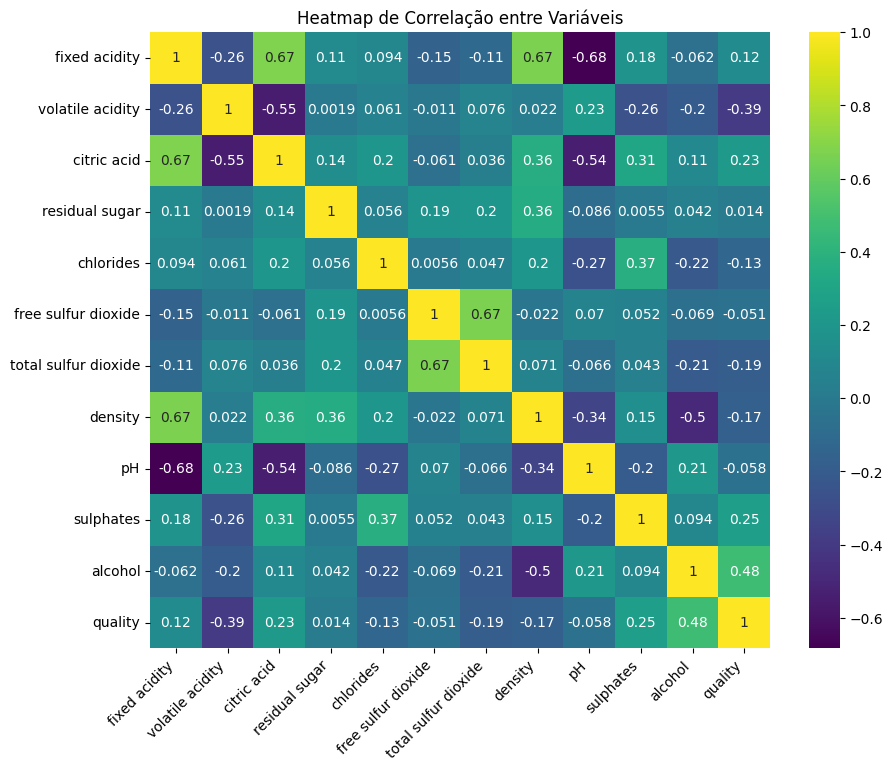

In [ ]:
#Heatmap de Correlação entre Variáveis

plt.figure(figsize=(10,8))
sns.heatmap(df_red.corr(), cmap='viridis', annot=True)
plt.title("Heatmap de Correlação entre Variáveis")
plt.xticks(rotation=45, ha='right')
plt.show()

###Análise do Heatmap:
Analisando o heatmap das variáveis, vemos uma significante correlação positiva entre o nivel de alcool e a qualidade do vinho (=0.48) e uma correlação bem negativa entre a Acidez Volátil e a qualidade(= -0.39), sugerindo que o teor alcoolico e o nivel de Acidez Volátil do vinho são os que mais afetam a qualidade.

 Já o nivel de Sulfatos e Acido Cítrico influenciam moderadamente de forma positiva, enquanto a Densidade e o Total de Dióxido de Enxofre influenciam também de forma moderada porem negativamente.

 A correlações identificadas serão bem importantes para orientar a escolha de features e analisar o desempenho de modelos posteriormente.

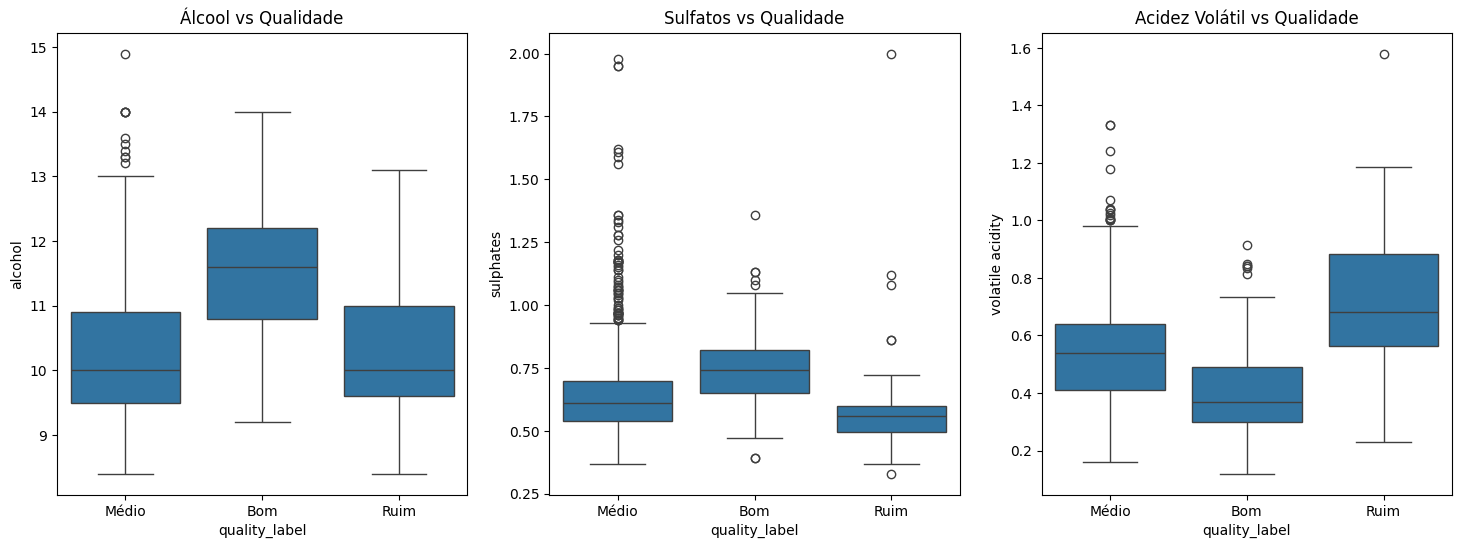

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df_red_w_label, x='quality_label', y='alcohol', ax=axes[0])
axes[0].set_title("Álcool vs Qualidade")

sns.boxplot(data=df_red_w_label, x='quality_label', y='sulphates', ax=axes[1])
axes[1].set_title("Sulfatos vs Qualidade")

sns.boxplot(data=df_red_w_label, x='quality_label', y='volatile acidity', ax=axes[2])
axes[2].set_title("Acidez Volátil vs Qualidade")

plt.show()

###Análise dos Boxplot:
Foram escolhidas as variáveis que contem maior correlação com a qualidade, em magnetude, para a análise dos Boxplot.

Visualmente ja podemos ver claramente como o boxplot do Álcool é bem formado, mostrando que os vinhos com label 'Bom' tendem a ter um nivel de álcool mais elevado, enquanto que o contrário acontece com a Acidez Volátil, mostrando que vinhos bons não tem uma acidez volátil elevada.
  
Por fim, os sulfatos exibem diferenças mais moderadas entre as classes, o que está de acordo com sua correlação intermediária com a qualidade. É possível notar alguma separação entre as classes, mas com maior sobreposição e presença de valores dispersos, indicando que essa variável tem impacto relevante, mas não determinante, na classificação.

## 4. Construção dos modelos

Construção de modelos de aprendizado de máquina para fazer a classificação dos dados.

###Normalização dos dados

In [ ]:
#Quantificação da qualidade em inteiros:


df_red_w_intlabel = df_red_w_label.copy()
df_red_w_intlabel['quality_label'] = df_red_w_intlabel['quality_label'].replace({'Ruim': 0, 'Médio': 1, 'Bom': 2})
#print(df_red_w_intlabel.head())

/tmp/ipython-input-1339921793.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_red_w_intlabel['quality_label'] = df_red_w_intlabel['quality_label'].replace({'Ruim': 0, 'Médio': 1, 'Bom': 2})


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Separando features e target
x = df_red_w_intlabel.drop(['quality', 'quality_label'], axis=1)
y = df_red_w_intlabel['quality_label']

#Divisão treino/teste
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Normalização dos dados
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) #Evita que atributos com grandes magnetudes dominem o treinamento

### Inicialização dos Modelos de Classificação

Vamos inicializar dois modelos de classificação, Regressão Logística e Random Forest Classifier, que são adequados para problemas de classificação multi-classe e funcionam bem com dados já normalizados.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Inicializando o modelo de Regressão Logística
logistic_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')

# Inicializando o modelo Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)

print("Modelos de classificação inicializados:")
print(f"- Logistic Regression: {logistic_model}")
print(f"- Random Forest Classifier: {random_forest_model}")

Modelos de classificação inicializados:
- Logistic Regression: LogisticRegression(multi_class='auto', random_state=42, solver='liblinear')
- Random Forest Classifier: RandomForestClassifier(random_state=42)


## 5. Treino e avaliação dos modelos

Treino dos modelos com os dados. Avaliando o desempenho usando técnicas como Cross-validation e SMOTE.

Treino Inicial:

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score

# --- Treinamento e Avaliação da Regressão Logística ---
print("\n--- Regressão Logística ---")
# Treinando o modelo
logistic_model.fit(x_train, y_train)

# Avaliação com Cross-Validation
cv_scores_lr = cross_val_score(logistic_model, x_train, y_train, cv=5, scoring='f1_weighted')
print(f"F1-Score Médio (Cross-Validation): {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Previsões no conjunto de teste
y_pred_lr = logistic_model.predict(x_test)

# Relatório de Classificação
print("Relatório de Classificação no conjunto de Teste:")
print(classification_report(y_test, y_pred_lr, target_names=['Ruim', 'Médio', 'Bom']))


# --- Treinamento e Avaliação do Random Forest Classifier ---
print("\n--- Random Forest Classifier ---")
# Treinando o modelo
random_forest_model.fit(x_train, y_train)

# Avaliação com Cross-Validation
cv_scores_rf = cross_val_score(random_forest_model, x_train, y_train, cv=5, scoring='f1_weighted')
print(f"F1-Score Médio (Cross-Validation): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Previsões no conjunto de teste
y_pred_rf = random_forest_model.predict(x_test)

# Relatório de Classificação
print("Relatório de Classificação no conjunto de Teste:")
print(classification_report(y_test, y_pred_rf, target_names=['Ruim', 'Médio', 'Bom']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


--- Regressão Logística ---
F1-Score Médio (Cross-Validation): 0.7995 (+/- 0.0150)
Relatório de Classificação no conjunto de Teste:
              precision    recall  f1-score   support

        Ruim       0.00      0.00      0.00        13
       Médio       0.86      0.96      0.91       264
         Bom       0.60      0.35      0.44        43

    accuracy                           0.84       320
   macro avg       0.49      0.44      0.45       320
weighted avg       0.79      0.84      0.81       320


--- Random Forest Classifier ---
F1-Score Médio (Cross-Validation): 0.8361 (+/- 0.0126)
Relatório de Classificação no conjunto de Teste:
              precision    recall  f1-score   support

        Ruim       0.00      0.00      0.00        13
       Médio       0.90      0.97      0.93       264
         Bom       0.76      0.65      0.70        43

    accuracy                           0.88       320
   macro avg       0.55      0.54      0.54       320
weighted avg       0.8

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Aplicação do SMOTE para balancear as classes

In [ ]:
# Instalar imblearn se ainda não estiver instalado
!pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Distribuição original das classes em y_train: {Counter(y_train)}")

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print(f"Distribuição das classes em y_train após SMOTE: {Counter(y_train_resampled)}")

Distribuição original das classes em y_train: Counter({1: 1055, 2: 174, 0: 50})
Distribuição das classes em y_train após SMOTE: Counter({1: 1055, 2: 1055, 0: 1055})


### Re-treinamento e Re-avaliação dos Modelos com Dados Balanceados

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score

# Re-inicializando os modelos para garantir que não há resíduos de treinamentos anteriores
logistic_model_smote = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')
random_forest_model_smote = RandomForestClassifier(random_state=42)

# --- Treinamento e Avaliação da Regressão Logística (com SMOTE) ---
print("\n--- Regressão Logística (com SMOTE) ---")
# Treinando o modelo com dados balanceados
logistic_model_smote.fit(x_train_resampled, y_train_resampled)

# Avaliação com Cross-Validation nos dados balanceados
cv_scores_lr_smote = cross_val_score(logistic_model_smote, x_train_resampled, y_train_resampled, cv=5, scoring='f1_weighted')
print(f"F1-Score Médio (Cross-Validation) após SMOTE: {cv_scores_lr_smote.mean():.4f} (+/- {cv_scores_lr_smote.std():.4f})")

# Previsões no conjunto de teste original
y_pred_lr_smote = logistic_model_smote.predict(x_test)

# Relatório de Classificação
print("Relatório de Classificação no conjunto de Teste (após SMOTE):")
print(classification_report(y_test, y_pred_lr_smote, target_names=['Ruim', 'Médio', 'Bom'], zero_division=0))


# --- Treinamento e Avaliação do Random Forest Classifier (com SMOTE) ---
print("\n--- Random Forest Classifier (com SMOTE) ---")
# Treinando o modelo com dados balanceados
random_forest_model_smote.fit(x_train_resampled, y_train_resampled)

# Avaliação com Cross-Validation nos dados balanceados
cv_scores_rf_smote = cross_val_score(random_forest_model_smote, x_train_resampled, y_train_resampled, cv=5, scoring='f1_weighted')
print(f"F1-Score Médio (Cross-Validation) após SMOTE: {cv_scores_rf_smote.mean():.4f} (+/- {cv_scores_rf_smote.std():.4f})")

# Previsões no conjunto de teste original
y_pred_rf_smote = random_forest_model_smote.predict(x_test)

# Relatório de Classificação
print("Relatório de Classificação no conjunto de Teste (após SMOTE):")
print(classification_report(y_test, y_pred_rf_smote, target_names=['Ruim', 'Médio', 'Bom'], zero_division=0))


--- Regressão Logística (com SMOTE) ---
F1-Score Médio (Cross-Validation) após SMOTE: 0.7115 (+/- 0.0200)
Relatório de Classificação no conjunto de Teste (após SMOTE):
              precision    recall  f1-score   support

        Ruim       0.16      0.77      0.26        13
       Médio       0.96      0.55      0.70       264
         Bom       0.34      0.84      0.48        43

    accuracy                           0.59       320
   macro avg       0.49      0.72      0.48       320
weighted avg       0.84      0.59      0.65       320


--- Random Forest Classifier (com SMOTE) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

F1-Score Médio (Cross-Validation) após SMOTE: 0.9410 (+/- 0.0095)
Relatório de Classificação no conjunto de Teste (após SMOTE):
              precision    recall  f1-score   support

        Ruim       0.30      0.23      0.26        13
       Médio       0.92      0.87      0.89       264
         Bom       0.53      0.74      0.62        43

    accuracy                           0.82       320
   macro avg       0.58      0.61      0.59       320
weighted avg       0.84      0.82      0.83       320



### Sumário de Desempenho Antes e Depois do SMOTE

A seguir, uma tabela resumindo as principais métricas de desempenho dos modelos de Regressão Logística e Random Forest Classifier, antes e depois da aplicação do SMOTE.

| Modelo                      | Métrica                    | Antes do SMOTE | Após SMOTE (Dados Balanceados) |
| :-------------------------- | :------------------------- | :------------- | :----------------------------- |
| **Regressão Logística**     | F1-Score Médio (CV)        | 0.7995         | 0.7115                         |
|                             | Acurácia Geral (Teste)     | 0.84           | 0.59                           |
|                             | F1-Score Classe 'Ruim'     | 0.00           | 0.26                           |
|                             | F1-Score Classe 'Médio'    | 0.91           | 0.70                           |
|                             | F1-Score Classe 'Bom'      | 0.44           | 0.48                           |
| **Random Forest Classifier**| F1-Score Médio (CV)        | 0.8361         | 0.9410                         |
|                             | Acurácia Geral (Teste)     | 0.88           | 0.82                           |
|                             | F1-Score Classe 'Ruim'     | 0.00           | 0.26                           |
|                             | F1-Score Classe 'Médio'    | 0.93           | 0.89                           |
|                             | F1-Score Classe 'Bom'      | 0.70           | 0.62                           |


###Análise:
Devido ao desbalanceamento do numero de dados relacionados a classe 'Ruim' ou com label 0 em comparação ao numero de dados com Classe 'Médio', o modelo inicial era ótimo em prever vinhos com qualidade média, porem completamente ignorava os vinhos ruins.
Então decidi aplicar o SMOTE para que os modelos pudessem identificar a classe 'Ruim'. Porem isso veio com um trade-off:
A degradação na performance da classe 'Medio'.

O Random Forest Classifier (RFC) teve se mostra o melhor modelo, embora sua acurácia geral tenha diminuido com o SMOTE, a capacidade de prever a classe 'Ruim' e o desempenho bom para a classe 'Bom' (Score F1 de 0.62) o tornam o mais equilibrado e útil para um cenário de classificação com 3 classes desbalanceadas.

A regressão logística teve uma queda de performance muito mais acentuada com após o SMOTE.

### Comparação de Desempenho e Importância das Features


--- Comparação de Desempenho Pós-SMOTE ---
Regressão Logística (Accuracy): 0.59
Random Forest Classifier (Accuracy): 0.82

--- Importância das Features (Random Forest) ---
sulphates               0.164557
alcohol                 0.156546
volatile acidity        0.139261
citric acid             0.081402
total sulfur dioxide    0.080509
pH                      0.073361
free sulfur dioxide     0.064626
density                 0.063402
residual sugar          0.062500
chlorides               0.058679
fixed acidity           0.055156
dtype: float64


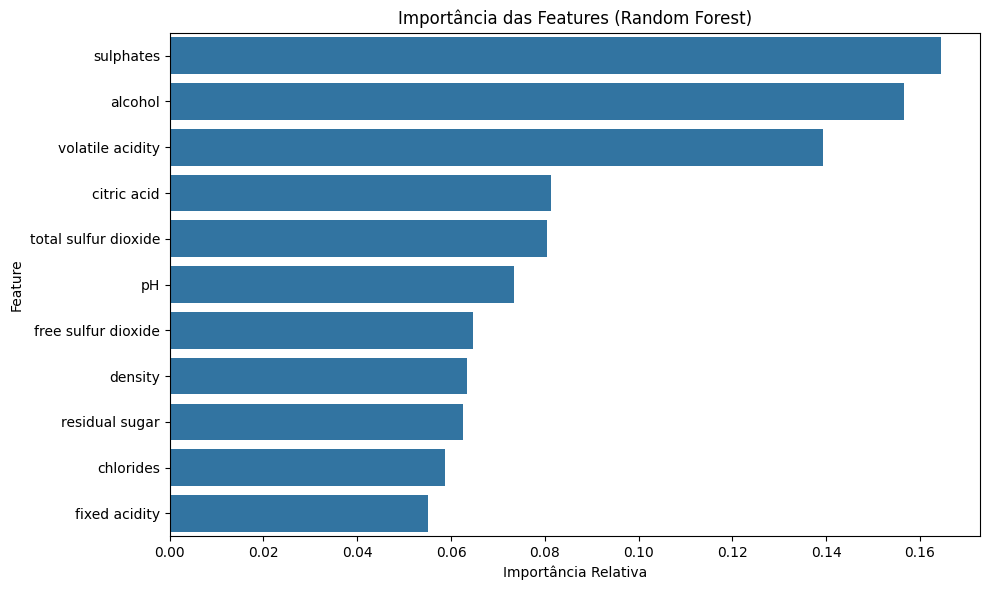


--- Coeficientes das Features (Regressão Logística) ---
alcohol                 0.974979
volatile acidity        0.875799
fixed acidity           0.840675
pH                      0.830356
density                 0.803737
total sulfur dioxide    0.677698
sulphates               0.629467
residual sugar          0.376841
citric acid             0.324157
free sulfur dioxide     0.313440
chlorides               0.258442
dtype: float64


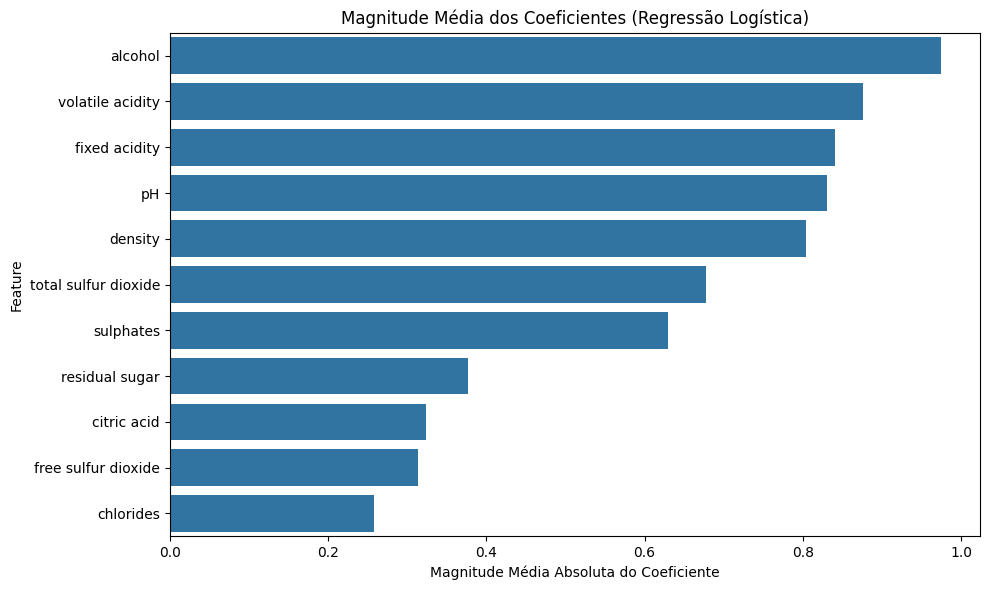

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Comparação de Desempenho ---
print("\n--- Comparação de Desempenho Pós-SMOTE ---")
print("Regressão Logística (Accuracy): 0.59")
print("Random Forest Classifier (Accuracy): 0.82")

# --- Análise de Importância das Features para Random Forest ---
print("\n--- Importância das Features (Random Forest) ---")
feature_importances_rf = pd.Series(random_forest_model_smote.feature_importances_, index=x.columns).sort_values(ascending=False)
print(feature_importances_rf)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_rf, y=feature_importances_rf.index)
plt.title('Importância das Features (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- Análise dos Coeficientes para Regressão Logística ---
print("\n--- Coeficientes das Features (Regressão Logística) ---")
# Para multi_class='auto' (que resolve para 'multinomial' com liblinear), LogisticRegression tem coeficientes por classe
# Vamos pegar a magnitude média dos coeficientes para cada feature
coefs_lr = pd.DataFrame(logistic_model_smote.coef_, columns=x.columns)
mean_abs_coefs_lr = coefs_lr.abs().mean().sort_values(ascending=False)
print(mean_abs_coefs_lr)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_abs_coefs_lr, y=mean_abs_coefs_lr.index)
plt.title('Magnitude Média dos Coeficientes (Regressão Logística)')
plt.xlabel('Magnitude Média Absoluta do Coeficiente')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


É possivel notar que as features identificadas como mais importantes anteriormente, na seção 3 aparecem aqui de novo.

O Alcool, Acidez Volátil e Sulfatos aparecem como os tres mais influentes na Random Forest, como previsto anteriormente com o heatmap.

Já na Regressão Logística o Sulfato não aparece ser tão influente quanto era porem o Alcool e Acidez Volátil ainda continuam dominando a influência na determinação da qualidade.

## 6. Conclussões finais

O objetivo original do trabalho era identificar quais das features cadastradas na database "Wine Quality" eram as mais influentes no nivel de qualidade do Álcool e as ferramentas de aprendizado de máquina foram cruciais para isso.

Uma análise inicial das variáveis ia ser impossivel sem os heatmaps e boxplot de suas correlações com a qualidade, o que foi essencial para orientar os modelos usados no treinamento e avaliação e posteriormente confirmar essa correlação.

Devido a má distruição das classes, o SMOTE foi essencial para a predição de classes com menor número ('Ruim') e a melhora no desempenho de classes que já não tinham bastante numeros ('Bom'), com o trade-off da leve diminuição geral da precisão mas que no fim vale a pena.

Em suma, as ferramentas desenvolvidas aqui foram essenciais para o estudo das variáveis e suas correlações com a qualidade, permitindo denotar quais são as mais influentes na qualidade do 'Vinho Verde' tinto, de Portugal.